In [14]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
scenario_folder_lake = select_scenario("lake_cluster", True)

Selected scenario: lake_cluster

Selected run: 2025-03-25_16:00


In [16]:
node_pos_df_lake = load_node_pos_df(scenario_folder_lake)
phy_tx_begin_lake = load_phy_tx_begin(scenario_folder_lake)
phy_rx_end_lake = load_phy_rx_end(scenario_folder_lake)

In [17]:
# Append the most recent node positions (X, Y, Z) for SourceNodeId and DestinationNodeId at the time of the packet in each of the dataframes. Add a column for Distance
def append_node_pos(packet_df, node_pos_df, column):
    packet_df[f'{column}_X'] = packet_df[column].map(node_pos_df.set_index('NodeId')['X'])
    packet_df[f'{column}_Y'] = packet_df[column].map(node_pos_df.set_index('NodeId')['Y'])
    packet_df[f'{column}_Z'] = packet_df[column].map(node_pos_df.set_index('NodeId')['Z'])
    packet_df[f'{column}_NodeType'] = packet_df[column].map(node_pos_df.set_index('NodeId')['NodeType'])
    
append_node_pos(phy_tx_begin_lake, node_pos_df_lake, 'SourceNodeId')
append_node_pos(phy_rx_end_lake, node_pos_df_lake, 'DestinationNodeId')

In [18]:
def calculate_packet_stats(tx_begin_df, rx_end_df):
    packet_df = rx_end_df.copy()
    # Drop the SnifferNodeId column
    packet_df.drop(columns=['SnifferNodeId'], inplace=True)
    # Rename Time into TxTime
    packet_df.rename(columns={'Time': 'RxTime'}, inplace=True)
    
    def get_tx_values(packet_id, df, column):
        values = df[df['PacketId'] == packet_id][column].values
        return values if len(values) > 0 else np.array([np.nan])
    
    # Append a column with the time the same PacketId is registered for the first time in tx_begin_df
    packet_df['TxTime'] = packet_df['PacketId'].apply(lambda x: get_tx_values(x, tx_begin_df, 'Time')[0])
    # If TxTime is NaN, set it to -inf
    packet_df['TxTime'] = packet_df['TxTime'].apply(lambda x: -np.inf if np.isnan(x) else x)
    # Calculate the time the packet spent in the air
    packet_df['AirTime'] = packet_df['RxTime'] - packet_df['TxTime']
    # Calculate the distance between the SourceNodeId and the DestinationNodeId
    # Append the SourceNodeId columns to the packet_df with the values from the latest entry in tx_begin_df with the same packetId
    packet_df['SourceNodeId_X'] = packet_df['PacketId'].apply(lambda x: get_tx_values(x, tx_begin_df, 'SourceNodeId_X')[-1])
    packet_df['SourceNodeId_Y'] = packet_df['PacketId'].apply(lambda x: get_tx_values(x, tx_begin_df, 'SourceNodeId_Y')[-1])
    packet_df['SourceNodeId_Z'] = packet_df['PacketId'].apply(lambda x: get_tx_values(x, tx_begin_df, 'SourceNodeId_Z')[-1])
    packet_df['SourceNodeId_NodeType'] = packet_df['PacketId'].apply(lambda x: get_tx_values(x, tx_begin_df, 'SourceNodeId_NodeType')[-1])
    # Drop packets where the SourceNodeId_... is NaN
    packet_df.dropna(subset=['SourceNodeId_X'], inplace=True)
    packet_df.dropna(subset=['SourceNodeId_Y'], inplace=True)
    packet_df.dropna(subset=['SourceNodeId_Z'], inplace=True)
    packet_df.dropna(subset=['SourceNodeId_NodeType'], inplace=True)
    packet_df['Distance'] = np.sqrt((packet_df['SourceNodeId_X'] - packet_df['DestinationNodeId_X'])**2 + (packet_df['SourceNodeId_Y'] - packet_df['DestinationNodeId_Y'])**2 + (packet_df['SourceNodeId_Z'] - packet_df['DestinationNodeId_Z'])**2)

    return packet_df

packet_stats_lake = calculate_packet_stats(phy_tx_begin_lake, phy_rx_end_lake)


In [19]:
# Group the packet_stats_lake by Distance. Then calculate the average throughput by dividing the sum of the packet sizes by the sum of the AirTime
def calculate_throughput(packet_stats_df):
    throughput_df = packet_stats_df[
            (packet_stats_df['SourceNodeId_NodeType'] == 'AP') & 
            (packet_stats_df['DestinationNodeId_NodeType'] == 'STA')
        ].groupby('Distance').agg({'PacketSize': 'sum', 'AirTime': 'sum'})
    # Convert AirTime from ns to s
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']
    return throughput_df

throughput_lake = calculate_throughput(packet_stats_lake)

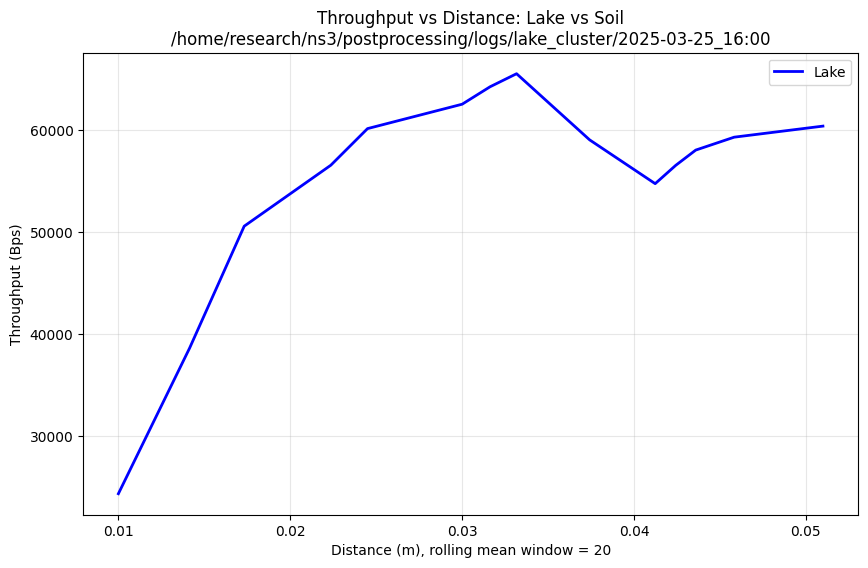

In [20]:
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
plt.plot(throughput_lake.index, throughput_lake['Throughput'].rolling(window=20, min_periods=1).mean(), 
         label='Lake', color='blue', linewidth=2)

plt.xlabel('Distance (m), rolling mean window = 20')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput vs Distance: Lake vs Soil\n{scenario_folder_lake}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()